In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/sahipaneer/labels/Label.xlsx


In [2]:
# T4 x2 — no version fixing needed, everything is compatible
!pip install -q ultralytics gdown

import torch
import numpy as np
from ultralytics import YOLO

print(f"PyTorch : {torch.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
print(f"GPU     : {torch.cuda.get_device_name(0)}")
print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# Sanity check
arr = torch.from_numpy(np.zeros((1,3,640,640), dtype=np.float32))
print("✅ NumPy → Torch works!")

model = YOLO("yolo12s.pt")
print("✅ YOLOv12s loaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch : 2.10.0+cu128
NumPy   : 2.0.2
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB
✅ NumPy → Torch works!
✅ YOLOv12s loaded!


In [3]:
import gdown, os, zipfile

os.makedirs("/kaggle/working/nutrivision", exist_ok=True)

print("⏳ Downloading dataset...")
gdown.download(
    "https://drive.google.com/uc?id=1pA0poR-eFOJaCPiAJN6uKMfefQCIS1IZ",
    "/kaggle/working/nutrivision_data.zip",
    quiet=False
)

print("⏳ Extracting...")
with zipfile.ZipFile("/kaggle/working/nutrivision_data.zip", 'r') as z:
    z.extractall("/kaggle/working/nutrivision")
print("✅ Done!")

import glob
for split in ["train", "valid", "test"]:
    imgs = glob.glob(f"/kaggle/working/nutrivision/**/{split}/images/*", recursive=True)
    print(f"  ✅ {split:6s}: {len(imgs):,} images")

⏳ Downloading dataset...


Downloading...
From (original): https://drive.google.com/uc?id=1pA0poR-eFOJaCPiAJN6uKMfefQCIS1IZ
From (redirected): https://drive.google.com/uc?id=1pA0poR-eFOJaCPiAJN6uKMfefQCIS1IZ&confirm=t&uuid=4ef562c1-3152-4ce2-9601-0457d6ed9b2c
To: /kaggle/working/nutrivision_data.zip
100%|██████████| 3.22G/3.22G [00:25<00:00, 128MB/s]


⏳ Extracting...
✅ Done!
  ✅ train : 29,804 images
  ✅ valid : 3,726 images
  ✅ test  : 3,726 images


In [4]:
import yaml, glob, os

yaml_files = glob.glob("/kaggle/working/nutrivision/**/*.yaml", recursive=True)
yaml_path  = yaml_files[0]
print(f"Found: {yaml_path}")

with open(yaml_path) as f:
    data = yaml.safe_load(f)

train_imgs   = glob.glob("/kaggle/working/nutrivision/**/train/images", recursive=True)
dataset_root = os.path.dirname(os.path.dirname(train_imgs[0]))

data["path"]  = dataset_root
data["train"] = "train/images"
data["val"]   = "valid/images"
data["test"]  = "test/images"

with open(yaml_path, "w") as f:
    yaml.dump(data, f, default_flow_style=False, sort_keys=False)

print(f"✅ data.yaml fixed!")
print(f"   path → {data['path']}")
print(f"   nc   → {data['nc']} classes")

Found: /kaggle/working/nutrivision/nutrivision_merged/data.yaml
✅ data.yaml fixed!
   path → /kaggle/working/nutrivision/nutrivision_merged
   nc   → 111 classes


In [5]:
from ultralytics import YOLO
import torch

print(f"🚀 Training YOLOv12s on new single-class dataset")
print(f"   GPU  : {torch.cuda.get_device_name(0)}")
print(f"   VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB\n")

model = YOLO("yolo12s.pt")   # fresh pretrained weights from ultralytics

results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=32,
    device=0,
    workers=4,
    amp=True,
    project="/kaggle/working/runs",
    name="nutrivision_main_50ep",
    exist_ok=True,
    optimizer="AdamW",
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    warmup_momentum=0.8,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10.0,
    scale=0.5,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    erasing=0.4,
    close_mosaic=10,
    patience=20,
    save=True,
    save_period=10,
    plots=True,
    val=False,
    verbose=True,
)

print(f"\n✅ Training complete!")
print(f"📁 Last : {results.save_dir}/weights/last.pt")

🚀 Training YOLOv12s on new single-class dataset
   GPU  : Tesla T4
   VRAM : 15.6 GB

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/nutrivision/nutrivision_merged/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=nut

⏳ Evaluating on TEST set...
Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12s summary (fused): 159 layers, 9,273,837 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1327.8±469.1 MB/s, size: 59.3 KB)
val: Scanning /kaggle/working/nutrivision/nutrivision_merged/test/labels... 3726 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3726/3726 1.5Kit/s 2.5s
val: /kaggle/working/nutrivision/nutrivision_merged/test/images/ds1_download-15-_jpeg.rf.420ad29a88d96c3b8f3eb89aa510c621.jpg: 1 duplicate labels removed
val: New cache created: /kaggle/working/nutrivision/nutrivision_merged/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 233/233 3.5it/s 1:07
                   all       3726       6875      0.877      0.836      0.891      0.746
Speed: 0.8ms preprocess, 14.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /k

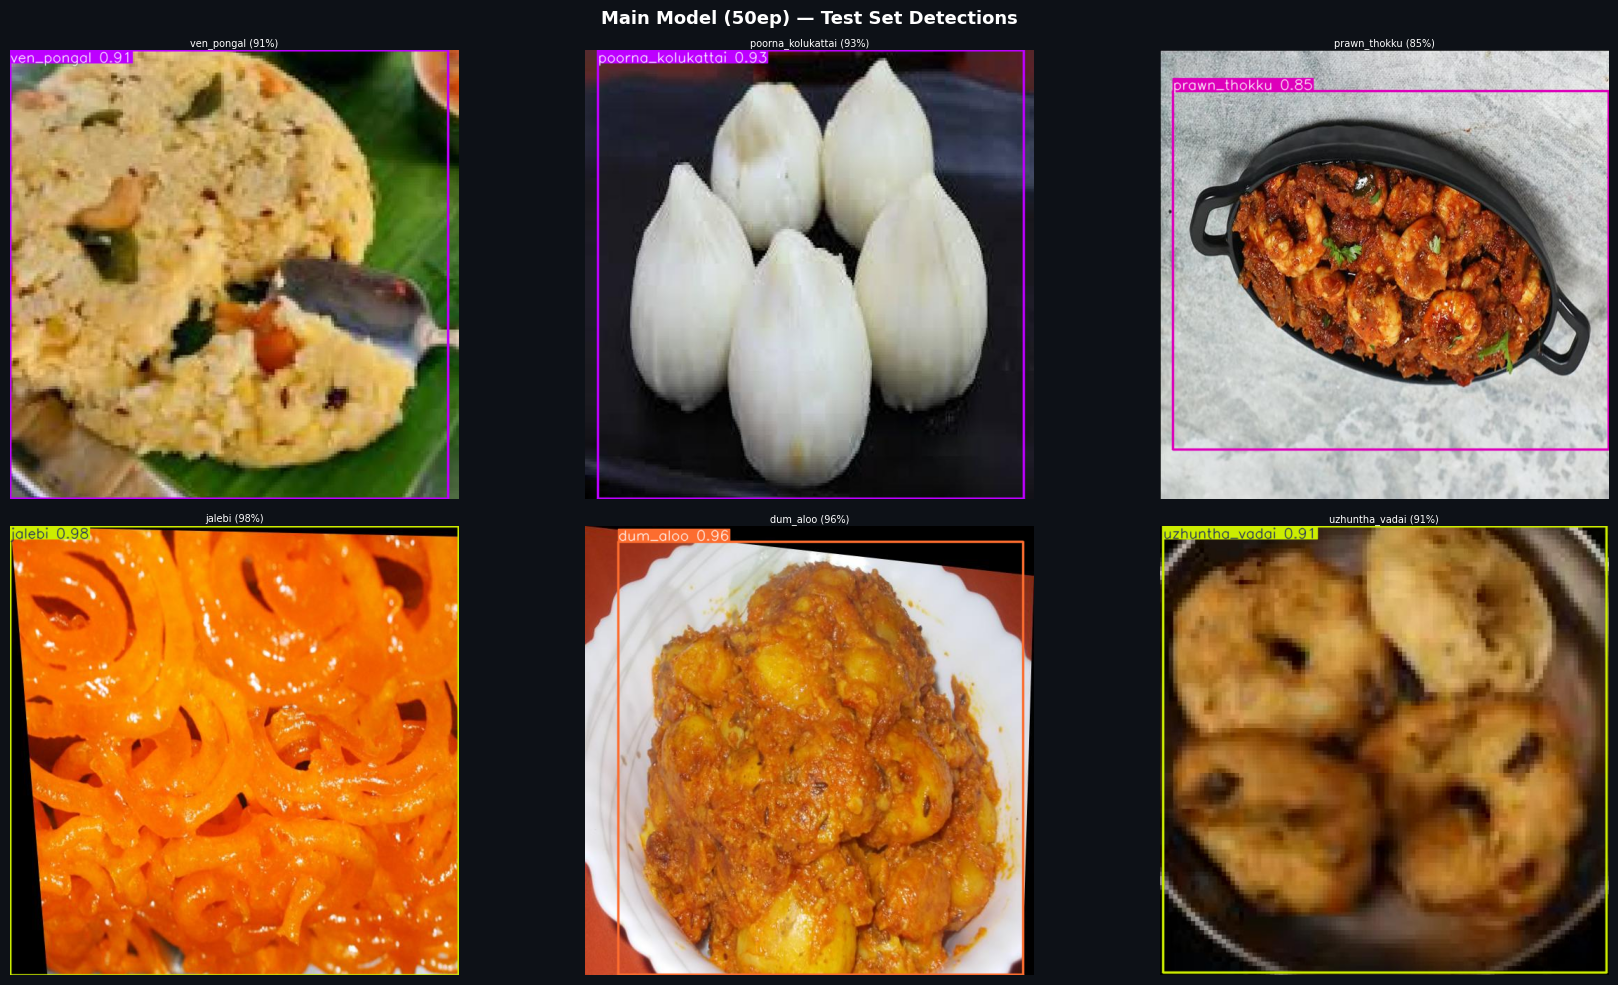

✅ Test evaluation complete!


In [6]:
from ultralytics import YOLO
import glob, random, cv2
import matplotlib.pyplot as plt

best_model = YOLO(f"{results.save_dir}/weights/last.pt")

print("⏳ Evaluating on TEST set...")
test_metrics = best_model.val(
    data=yaml_path,
    imgsz=640,
    split="test",
    conf=0.25,
    iou=0.5,
    plots=True,
    verbose=False,
)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║     NutriVision — Main Model Test Results                    ║
╠══════════════════════════════════════════════════════════════╣
║  mAP@50      : {test_metrics.box.map50*100:5.1f}%                                   ║
║  mAP@50-95   : {test_metrics.box.map*100:5.1f}%   ← key metric                    ║
║  Precision   : {test_metrics.box.mp*100:5.1f}%                                   ║
║  Recall      : {test_metrics.box.mr*100:5.1f}%                                   ║
╚══════════════════════════════════════════════════════════════╝
""")

# Visual grid
test_imgs = glob.glob(f"{data['path']}/test/images/*.jpg")
if not test_imgs:
    test_imgs = glob.glob(f"{data['path']}/**/test/images/*.jpg", recursive=True)
samples = random.sample(test_imgs, min(6, len(test_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0d1117')
fig.suptitle("Main Model (50ep) — Test Set Detections",
             fontsize=13, fontweight='bold', color='white')

for ax, img_path in zip(axes.flatten(), samples):
    result  = best_model.predict(source=img_path, conf=0.25, verbose=False)[0]
    img_rgb = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb); ax.axis('off')
    ax.set_facecolor('#161b22')
    if result.boxes and len(result.boxes):
        classes = [best_model.names[int(c)] for c in result.boxes.cls]
        confs   = [float(c) for c in result.boxes.conf]
        title   = "\n".join([f"{c} ({v:.0%})" for c,v in zip(classes,confs)])[:80]
        ax.set_title(title, color='white', fontsize=7, pad=3)
    else:
        ax.set_title("⚠️ No detection", color='red', fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/main_model_test_results.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Test evaluation complete!")

In [7]:
import shutil, os

out = "/kaggle/working/nutrivision_main_output"
os.makedirs(f"{out}/weights", exist_ok=True)
os.makedirs(f"{out}/plots",   exist_ok=True)

# Weights
shutil.copy(f"{results.save_dir}/weights/last.pt", f"{out}/weights/main_last.pt")
best_pt = f"{results.save_dir}/weights/best.pt"
if os.path.exists(best_pt):
    shutil.copy(best_pt, f"{out}/weights/main_best.pt")

# Auto-generated YOLO plots
for fname in ["results.png", "confusion_matrix.png",
              "PR_curve.png", "F1_curve.png"]:
    src = os.path.join(results.save_dir, fname)
    if os.path.exists(src):
        shutil.copy(src, f"{out}/plots/{fname}")

# Test grid
shutil.copy("/kaggle/working/main_model_test_results.png",
            f"{out}/plots/test_detection_grid.png")

# List everything
print("📁 Kaggle Output — ready to download:")
for root, dirs, files in os.walk(out):
    for f in files:
        path = os.path.join(root, f)
        print(f"  {path.replace(out+'/', '')}  ({os.path.getsize(path)/1e6:.1f} MB)")

print(f"""
╔══════════════════════════════════════════════════════════════╗
║  Download from Output tab → upload to Drive → share team     ║
║                                                              ║
║  mAP@50-95 (test) : {test_metrics.box.map*100:5.1f}%  ← share with team          ║
║  mAP@50    (test) : {test_metrics.box.map50*100:5.1f}%                             ║
╚══════════════════════════════════════════════════════════════╝
""")
```

---

SyntaxError: invalid syntax (1718537940.py, line 39)